# CMPE-679 Lab 2 — Transformer
**Name:** Gloria Mbaka  
**Date:** March 19, 2026


## Objectives
- Implement an encoder-decoder Transformer.
- Train and evaluate on WMT14 de-en.
- Generate example translations and report results.


## Setup
- Download WMT14 EN-DE data
- External scripts for tokenizer, pretokenization, and training
- All outputs saved under `GloriaMbaka_LAB2`


## Workflow
1. Run path setup
2. Download Data
2. Train tokenizer
3. Pretokenize dataset
4. Run training script
5. Evaluate checkpoints and generate translations


In [1]:
# =========================
# Device + seed cell
# =========================
import os, math, random, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## Data Pipeline — WMT14 de-en (starter code, cleaned)
This notebook is set up to run on **Google Colab**, **Lightning AI Studio**, or a normal **local Jupyter environment**.
It uses a BPE tokenizer trained from the dataset and `DataCollatorForSeq2Seq` to create padded batches.


In [2]:
from datasets import load_dataset, concatenate_datasets
from transformers import DataCollatorForSeq2Seq, PreTrainedTokenizerFast
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from torch.utils.data import DataLoader


In [3]:
def detect_runtime():
    if 'COLAB_GPU' in os.environ:
        return 'colab'
    if os.path.exists('/teamspace/studios/this_studio'):
        return 'lightning'
    return 'local'

RUNTIME = detect_runtime()
print('Detected runtime:', RUNTIME)

if RUNTIME == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = '/content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB2'
elif RUNTIME == 'lightning':
    ROOT = '/teamspace/studios/this_studio/GloriaMbaka_LAB2'
else:
    ROOT = os.path.abspath('./GloriaMbaka_LAB2')

DATA_DIR = os.path.join(ROOT, 'data')
CHECKPOINT_DIR = os.path.join(ROOT, 'checkpoints')
TOKENIZER_DIR = os.path.join(ROOT, 'tokenizer')
TOKENIZED_CACHE_DIR = os.path.join(ROOT, 'tokenized_cache')
REPORT_DIR = os.path.join(ROOT, 'reports')

TOKENIZER_SCRIPT = os.path.join(ROOT, 'train_tokenizer.py')
PRETOKENIZE_SCRIPT = os.path.join(ROOT, 'pretokenize_dataset.py')
TRAIN_SCRIPT = os.path.join(ROOT, 'train_transformer.py')

TRAIN_EN = os.path.join(DATA_DIR, 'train.en')
TRAIN_DE = os.path.join(DATA_DIR, 'train.de')
VAL_EN = os.path.join(DATA_DIR, 'val.en')
VAL_DE = os.path.join(DATA_DIR, 'val.de')
TEST_EN = os.path.join(DATA_DIR, 'test.en')
TEST_DE = os.path.join(DATA_DIR, 'test.de')

TOKENIZER_PATH = os.path.join(TOKENIZER_DIR, 'my_trained_tokenizer.json')
FINAL_MODEL_PATH = os.path.join(ROOT, 'lab2_en_de_final.pth')
LATEST_CKPT = os.path.join(CHECKPOINT_DIR, 'lab2_en_de_latest.pt')
BEST_CKPT = os.path.join(CHECKPOINT_DIR, 'lab2_en_de_best.pt')
TRAIN_LOG = os.path.join(ROOT, 'train_log.txt')

for folder in [ROOT, DATA_DIR, CHECKPOINT_DIR, TOKENIZER_DIR, TOKENIZED_CACHE_DIR, REPORT_DIR]:
    os.makedirs(folder, exist_ok=True)

print('ROOT:', ROOT)
print('DATA_DIR:', DATA_DIR)
print('TOKENIZER_SCRIPT:', TOKENIZER_SCRIPT)
print('PRETOKENIZE_SCRIPT:', PRETOKENIZE_SCRIPT)
print('TRAIN_SCRIPT:', TRAIN_SCRIPT)
print('TOKENIZER_PATH:', TOKENIZER_PATH)
print('TOKENIZED_CACHE_DIR:', TOKENIZED_CACHE_DIR)
print('LATEST_CKPT:', LATEST_CKPT)


Detected runtime: colab
Mounted at /content/drive
ROOT: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB2
DATA_DIR: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB2/data
TOKENIZER_SCRIPT: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB2/train_tokenizer.py
PRETOKENIZE_SCRIPT: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB2/pretokenize_dataset.py
TRAIN_SCRIPT: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB2/train_transformer.py
TOKENIZER_PATH: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB2/tokenizer/my_trained_tokenizer.json
TOKENIZED_CACHE_DIR: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB2/tokenized_cache
LATEST_CKPT: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB2/checkpoints/lab2_en_de_latest.pt


## Download and split dataset

In [4]:
# Download WMT14 de-en and write official splits into DATA_DIR
from datasets import load_dataset
import os

required_files = [TRAIN_EN, TRAIN_DE, VAL_EN, VAL_DE, TEST_EN, TEST_DE]

def count_lines(path):
    with open(path, "r", encoding="utf-8") as f:
        return sum(1 for _ in f)

def files_ok():
    if not all(os.path.exists(p) for p in required_files):
        return False

    splits = [
        (TRAIN_EN, TRAIN_DE, "train"),
        (VAL_EN, VAL_DE, "val"),
        (TEST_EN, TEST_DE, "test"),
    ]

    ok = True
    for en_path, de_path, name in splits:
        en_count = count_lines(en_path)
        de_count = count_lines(de_path)
        print(f"{name}: {en_count} EN | {de_count} DE")
        if en_count != de_count:
            print(f"Mismatch in {name}")
            ok = False

    return ok

def remove_old():
    for p in required_files:
        if os.path.exists(p):
            os.remove(p)
            print("Removed:", p)

if files_ok():
    print('Data files already exist and are aligned in', DATA_DIR)
else:
    print("Downloading and writing official WMT14 splits...")
    remove_old()

    ds = load_dataset('wmt14', 'de-en')

    def write_parallel(split_ds, en_path, de_path):
        kept = 0
        dropped = 0

        with open(en_path, 'w', encoding='utf-8') as fen, open(de_path, 'w', encoding='utf-8') as fde:
            for row in split_ds:
                pair = row.get('translation', None)

                if pair is None or 'en' not in pair or 'de' not in pair:
                    dropped += 1
                    continue

                en = pair['en']
                de = pair['de']

                if not isinstance(en, str) or not isinstance(de, str):
                    dropped += 1
                    continue

                # remove hidden newlines (CRITICAL FIX)
                en = ' '.join(en.replace('\r', ' ').replace('\n', ' ').split())
                de = ' '.join(de.replace('\r', ' ').replace('\n', ' ').split())

                if not en or not de:
                    dropped += 1
                    continue

                fen.write(en + '\n')
                fde.write(de + '\n')
                kept += 1

        print(f"{os.path.basename(en_path)} / {os.path.basename(de_path)}")
        print(f"  kept: {kept}  dropped: {dropped}")

    # use official splits directly
    write_parallel(ds["train"], TRAIN_EN, TRAIN_DE)
    write_parallel(ds["validation"], VAL_EN, VAL_DE)
    write_parallel(ds["test"], TEST_EN, TEST_DE)

    print('\nSaved:')
    for p in required_files:
        print(' ', p)

print("\nFinal check:")
splits = [
    (TRAIN_EN, TRAIN_DE, "train"),
    (VAL_EN, VAL_DE, "val"),
    (TEST_EN, TEST_DE, "test"),
]

for en_path, de_path, name in splits:
    en_count = count_lines(en_path)
    de_count = count_lines(de_path)
    status = "OK" if en_count == de_count else "MISMATCH"
    print(f"{name}: {en_count} EN | {de_count} DE -> {status}")

train: 4508785 EN | 4508785 DE
val: 3000 EN | 3000 DE
test: 3003 EN | 3003 DE
Data files already exist and are aligned in /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB2/data

Final check:
train: 4508785 EN | 4508785 DE -> OK
val: 3000 EN | 3000 DE -> OK
test: 3003 EN | 3003 DE -> OK


## Train tokenizer


In [5]:
# Train tokenizer ONLY if not already saved
if not os.path.exists(TOKENIZER_PATH):
    if not os.path.exists(TOKENIZER_SCRIPT):
        raise FileNotFoundError(f"Tokenizer training script not found: {TOKENIZER_SCRIPT}")

    print("Tokenizer not found. Training...")
    !python "{TOKENIZER_SCRIPT}"
else:
    print("Tokenizer already exists. Skipping training.")

Tokenizer already exists. Skipping training.


# Pretokenizer

In [6]:
# Build tokenized cache
if not os.path.exists(PRETOKENIZE_SCRIPT):
    raise FileNotFoundError(f"Pretokenization script not found: {PRETOKENIZE_SCRIPT}")

!python "{PRETOKENIZE_SCRIPT}"


Tokenizer path: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB2/tokenizer/my_trained_tokenizer.json
Cache dir: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB2/tokenized_cache
FORCE_REBUILD_CACHE: False
pad_token: [PAD] 0
unk_token: [UNK] 1
bos_token: [BOS] 2
eos_token: [EOS] 3

Existing tokenized cache found. Skipping rebuild:
/content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB2/tokenized_cache

Cached metadata:
{
  "tokenizer_path": "/content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB2/tokenizer/my_trained_tokenizer.json",
  "max_src_len": 128,
  "max_tgt_len": 128,
  "pad_token_id": 0,
  "bos_token_id": 2,
  "eos_token_id": 3,
  "num_train": 4508785,
  "num_validation": 3000,
  "num_test": 3003
}

Sample tokenized example from cache:
input_ids: [2, 16152, 2733, 306, 279, 8058, 3]
attention_mask: [1, 1, 1, 1, 1, 1, 1]
labels: [2, 24182, 313, 23161, 3]

Decoded source sample:
[BOS] resumption of the session[E

## Train EN → DE model (external script)

This notebook now uses a clean three-step script workflow:

1. train the tokenizer  
2. pretokenize and build the fresh cached split  
3. train the Transformer model  

All paths come from `ROOT`, so there is no extra hardcoded path logic in the training cells.


In [7]:
# Optional package install cell for script-based workflow
!pip install -q datasets transformers tokenizers sentencepiece sacrebleu accelerate nbconvert


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.2 MB/s eta 0:00:00


In [8]:
# Start training in the background and write the log inside ROOT
import os

if not os.path.exists(TRAIN_SCRIPT):
    raise FileNotFoundError(f"Training script not found: {TRAIN_SCRIPT}")


%env EPOCHS=5
%env USE_AMP=False
%env TRAIN_CHUNK_SIZE=500000
%env SHUFFLE_CHUNKS=true
%env CHUNK_SHUFFLE_SEED=42
%env WARMUP_STEPS=8000

!nohup bash -lc 'cd "{ROOT}" && python -u "{TRAIN_SCRIPT}" > "{TRAIN_LOG}" 2>&1' &
print("Training started in background.")
print("Log file:", TRAIN_LOG)

env: EPOCHS=5
env: USE_AMP=False
env: TRAIN_CHUNK_SIZE=500000
env: SHUFFLE_CHUNKS=true
env: CHUNK_SHUFFLE_SEED=42
env: WARMUP_STEPS=8000
nohup: appending output to 'nohup.out'
Training started in background.
Log file: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB2/train_log.txt


In [9]:
# Watch training progress
!tail -f "{TRAIN_LOG}"


ROOT: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB2
DEVICE: cuda
TOKENIZER_PATH: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB2/tokenizer/my_trained_tokenizer.json
TOKENIZED_DIR: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB2/tokenized_cache
USE_AMP: False
USE_LR_SCHEDULER: True
EPOCHS: 5
BATCH_SIZE: 64
GRAD_ACCUM_STEPS: 8
EFFECTIVE_BATCH_SIZE: 512
TRAIN_CHUNK_SIZE: 500000
WARMUP_STEPS: 8000
BASE_LR: 0.0005
SHUFFLE_CHUNKS: False
CHUNK_SHUFFLE_SEED: 42
Loading tokenized dataset from disk...
Train examples: 4508785
Validation examples: 3000
Test examples: 3003
Loaded full checkpoint from: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB2/checkpoints/lab2_en_de_latest.pt
Restored model / optimizer / scheduler / scaler state.
Epoch to resume: 4
Resume offset within epoch: 4000000
Samples trained so far: 4000000
Current LR: 2.311077e-04
Checkpoint batch_size: 64
Checkpoint effective_batch_size: 512
Com

## Example translations after training

Run the next cell **after training finishes**. It will:

- load the current `train_transformer.py`
- load the tokenizer
- load the **best checkpoint** if available, otherwise the latest checkpoint
- translate 10 English test sentences into German
- also let you try your own custom English sentences


In [31]:
# ================================
# INSTALL GOOGLETRANS INTO AN ISOLATED FOLDER
# ================================
import os
import sys
import shutil
import subprocess

GT_DIR = "/tmp/googletrans_pkgs"

# start clean
if os.path.exists(GT_DIR):
    shutil.rmtree(GT_DIR)
os.makedirs(GT_DIR, exist_ok=True)

# install only into this folder
subprocess.run(
    [sys.executable, "-m", "pip", "install", "--upgrade", "--target", GT_DIR, "googletrans==4.0.0rc1"],
    check=True
)

# verify isolated import
code = r'''
import sys
sys.path.insert(0, r"/tmp/googletrans_pkgs")
from googletrans import Translator
print("googletrans import OK")
'''
result = subprocess.run(
    [sys.executable, "-c", code],
    capture_output=True,
    text=True
)

print("returncode:", result.returncode)
print("stdout:", result.stdout)
print("stderr:", result.stderr)
print("GT_DIR:", GT_DIR)

returncode: 0
stdout: googletrans import OK

stderr: 
GT_DIR: /tmp/googletrans_pkgs


In [32]:
# ================================
# GOOGLE TRANSLATE HELPER
# ================================
import subprocess
import sys

GT_DIR = "/tmp/googletrans_pkgs"

def google_translate_text(text: str) -> str:
    code = r'''
import sys
sys.path.insert(0, r"/tmp/googletrans_pkgs")
from googletrans import Translator

text = sys.argv[1]
translator = Translator()
out = translator.translate(text, src="en", dest="de").text
print(out)
'''
    result = subprocess.run(
        [sys.executable, "-c", code, text],
        capture_output=True,
        text=True
    )

    if result.returncode != 0:
        return f"[Google Translate failed: {result.stderr.strip()}]"

    return result.stdout.strip()

In [33]:
# ================================
# GOOGLE BACK-TRANSLATION (DE -> EN)
# ================================
import subprocess
import sys
import time

GT_DIR = "/tmp/googletrans_pkgs"

def google_translate_back(text: str) -> str:
    retries = 3
    wait_sec = 2.0

    code = r'''
import sys
sys.path.insert(0, r"/tmp/googletrans_pkgs")
from googletrans import Translator

text = sys.argv[1]
translator = Translator()
out = translator.translate(text, src="de", dest="en").text
print(out)
'''

    last_error = ""

    for attempt in range(retries):
        result = subprocess.run(
            [sys.executable, "-c", code, text],
            capture_output=True,
            text=True
        )

        if result.returncode == 0:
            return result.stdout.strip()

        # store error and retry
        last_error = result.stderr.strip()
        time.sleep(wait_sec)

    return f"[Back-translation failed after {retries} attempts: {last_error}]"

In [36]:
# ================================
# LOAD TRAINED MODEL AND RUN TRANSLATIONS
# + GOOGLE TRANSLATE
# + BACK-TRANSLATION
# + ONLY PRINT COMPLETED MODEL TRANSLATIONS
# ================================
import os
import importlib.util
import torch
import random
from transformers import PreTrainedTokenizerFast

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Inference device:", device)

if not os.path.exists(TRAIN_SCRIPT):
    raise FileNotFoundError(f"Training script not found: {TRAIN_SCRIPT}")

spec = importlib.util.spec_from_file_location("lab2_tt_module", TRAIN_SCRIPT)
tt = importlib.util.module_from_spec(spec)
spec.loader.exec_module(tt)

tokenizer = PreTrainedTokenizerFast(tokenizer_file=TOKENIZER_PATH)
tokenizer.pad_token = "[PAD]"
tokenizer.unk_token = "[UNK]"
tokenizer.bos_token = "[BOS]"
tokenizer.eos_token = "[EOS]"

checkpoint_to_use = BEST_CKPT if os.path.exists(BEST_CKPT) else LATEST_CKPT
if not os.path.exists(checkpoint_to_use):
    raise FileNotFoundError("No trained checkpoint found.")

print("Checkpoint used for translation:", checkpoint_to_use)

model = tt.build_model(tokenizer)
ckpt = torch.load(checkpoint_to_use, map_location=device)

state_key = "model_state" if "model_state" in ckpt else "model"
model.load_state_dict(ckpt[state_key])
model.to(device)
model.eval()

print("Loaded checkpoint epoch:", ckpt.get("epoch"))
print("Best val loss:", ckpt.get("best_val_loss"))

# ---------- HELPERS ----------
def decode_to_text(token_ids):
    if isinstance(token_ids, torch.Tensor):
        token_ids = token_ids.tolist()

    cleaned = []
    for tok in token_ids:
        if tok == tokenizer.bos_token_id:
            continue
        if tok == tokenizer.eos_token_id:
            break
        if tok == tokenizer.pad_token_id:
            continue
        cleaned.append(tok)

    return tokenizer.decode(cleaned, skip_special_tokens=True).strip()

def prepare_src(src_text):
    src_ids = tokenizer(
        src_text,
        return_tensors="pt",
        max_length=126,
        truncation=True,
        add_special_tokens=False,
    )["input_ids"]

    bos = torch.tensor([[tokenizer.bos_token_id]], dtype=torch.long)
    eos = torch.tensor([[tokenizer.eos_token_id]], dtype=torch.long)

    return torch.cat([bos, src_ids.cpu(), eos], dim=1).to(device)

@torch.no_grad()
def greedy_decode(model, src_text, max_len=96, min_len=6):
    src = prepare_src(src_text)
    enc_out, src_mask = model.encode(src)

    tgt = torch.tensor([[model.bos_id]], dtype=torch.long, device=device)

    for step in range(max_len):
        dec_out = model.decode(tgt, enc_out, src_mask)
        logits = model.proj(dec_out[:, -1, :])

        if step < min_len:
            logits[0, model.eos_id] = -1e9

        next_tok = torch.argmax(logits, dim=-1, keepdim=True)
        tgt = torch.cat([tgt, next_tok], dim=1)

        if next_tok.item() == model.eos_id:
            break

    return tgt.squeeze(0).tolist()

@torch.no_grad()
def beam_decode(model, src_text, beam_size=3, max_len=96, min_len=6, length_penalty=0.9):
    src = prepare_src(src_text)
    enc_out, src_mask = model.encode(src)

    beams = [(torch.tensor([[model.bos_id]], dtype=torch.long, device=device), 0.0)]

    for step in range(max_len):
        new_beams = []

        for tgt, score in beams:
            if tgt[0, -1].item() == model.eos_id:
                new_beams.append((tgt, score))
                continue

            dec_out = model.decode(tgt, enc_out, src_mask)
            logits = model.proj(dec_out[:, -1, :])

            if step < min_len:
                logits[0, model.eos_id] = -1e9

            log_probs = torch.log_softmax(logits, dim=-1)
            topk = torch.topk(log_probs, beam_size)

            for k in range(beam_size):
                token = topk.indices[0, k].item()
                new_score = score + topk.values[0, k].item()

                new_tgt = torch.cat(
                    [tgt, torch.tensor([[token]], dtype=torch.long, device=device)], dim=1
                )
                new_beams.append((new_tgt, new_score))

        beams = sorted(
            new_beams,
            key=lambda x: x[1] / ((x[0].size(1)) ** length_penalty),
            reverse=True
        )[:beam_size]

        if all(b[0][0, -1].item() == model.eos_id for b in beams):
            break

    return beams[0][0].squeeze(0).tolist()

def model_translate(src_text):
    pred_ids = beam_decode(model, src_text)
    pred = decode_to_text(pred_ids)

    if pred == "":
        pred_ids = greedy_decode(model, src_text)
        pred = decode_to_text(pred_ids)

    return pred

def load_parallel_lines(src_path, tgt_path):
    with open(src_path, "r", encoding="utf-8") as f:
        src_lines = [l.strip() for l in f if l.strip()]
    with open(tgt_path, "r", encoding="utf-8") as f:
        tgt_lines = [l.strip() for l in f if l.strip()]
    n = min(len(src_lines), len(tgt_lines))
    return src_lines[:n], tgt_lines[:n]

# google helpers must already exist:
# - google_translate_text(text): EN -> DE
# - google_translate_back(text): DE -> EN

# ---------- LOAD DATA ----------
test_src_lines, test_tgt_lines = load_parallel_lines(TEST_EN, TEST_DE)

# ---------- FILTERED DATASET SAMPLING ----------
NUM_SAMPLES = 10
MAX_TRIES = 300

total = len(test_src_lines)
used_indices = set()
selected = []
tries = 0

print("\n===== FILTERED EN -> DE WITH GOOGLE TRANSLATE =====")

while len(selected) < NUM_SAMPLES and tries < MAX_TRIES:
    tries += 1
    idx = random.randint(0, total - 1)

    if idx in used_indices:
        continue
    used_indices.add(idx)

    src = test_src_lines[idx]
    ref = test_tgt_lines[idx]

    pred = model_translate(src)

    # keep only completed / usable translations
    if pred == "":
        continue
    if len(pred.split()) < 4:
        continue

    selected.append((idx, src, ref, pred))

    if len(selected) % 2 == 0 or len(selected) == NUM_SAMPLES:
        print(f"Collected {len(selected)}/{NUM_SAMPLES} valid model translations after {tries} attempts...")

print(f"Collected {len(selected)} completed model translations after {tries} attempts.")

if len(selected) < NUM_SAMPLES:
    print(f"Warning: only {len(selected)} completed translations were found.")

# ---------- GOOGLE TRANSLATE + BACK-TRANSLATION AFTER FILTERING ----------
selected_with_google = []
for idx, src, ref, pred in selected:
    google_pred = google_translate_text(src)
    back_en = google_translate_back(pred)
    selected_with_google.append((idx, src, ref, pred, google_pred, back_en))

# ---------- PRINT DATASET EXAMPLES ----------
for i, (idx, src, ref, pred, google_pred, back_en) in enumerate(selected_with_google, 1):
    print(f"\n[{i}] Index {idx}")
    print(f"    English        : {src}")
    print(f"    German ref     : {ref}")
    print(f"    German model   : {pred}")
    print(f"    Back->English  : {back_en}")
    print(f"    German Google  : {google_pred}")

# ---------- CUSTOM TRANSLATIONS ----------
print("\n===== Custom translations (10 sentences) =====")

custom_inputs = [
    "I love studying deep learning.",
    "The weather is very nice today.",
    "She is reading a book in the library.",
    "We are working on a machine learning project.",
    "The model learns patterns from data.",
    "He went to the market to buy food.",
    "Artificial intelligence is transforming technology.",
    "The students are preparing for their exam.",
    "This system translates English sentences into German.",
    "The meeting will start at ten in the morning.",
]

printed_custom = 0
custom_selected = []

for i, src in enumerate(custom_inputs, 1):
    pred = model_translate(src)

    # only keep completed custom translations too
    if pred == "":
        continue
    if len(pred.split()) < 4:
        continue

    custom_selected.append((src, pred))

for src, pred in custom_selected:
    google_pred = google_translate_text(src)
    back_en = google_translate_back(pred)

    printed_custom += 1
    print(f"\nCustom {printed_custom} English : {src}")
    print(f"          Model    : {pred}")
    print(f"          Back EN  : {back_en}")
    print(f"          Google   : {google_pred}")

if printed_custom == 0:
    print("\nNo completed custom translations were produced.")

Inference device: cuda
ROOT: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB2
DEVICE: cuda
TOKENIZER_PATH: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB2/tokenizer/my_trained_tokenizer.json
TOKENIZED_DIR: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB2/tokenized_cache
USE_AMP: False
USE_LR_SCHEDULER: True
EPOCHS: 5
BATCH_SIZE: 64
GRAD_ACCUM_STEPS: 8
EFFECTIVE_BATCH_SIZE: 512
TRAIN_CHUNK_SIZE: 500000
WARMUP_STEPS: 8000
BASE_LR: 0.0005
SHUFFLE_CHUNKS: False
CHUNK_SHUFFLE_SEED: 42
Checkpoint used for translation: /content/drive/MyDrive/Colab Notebooks/CMPE-679-Labs/GloriaMbaka_LAB2/checkpoints/lab2_en_de_best.pt
Loaded checkpoint epoch: 5
Best val loss: 2.673272409337632

===== FILTERED EN -> DE WITH GOOGLE TRANSLATE =====
Collected 2/10 valid model translations after 31 attempts...
Collected 4/10 valid model translations after 64 attempts...
Collected 6/10 valid model translations after 87 attempts...
Collected 8/10 valid 

In [38]:
# BLEU evaluation on RANDOM EN -> DE test subset after training
import sacrebleu
import random

BLEU_SAMPLES = 200
RANDOM_SEED = 42

# Load full dataset (NO limit here)
test_src_lines, test_tgt_lines = load_parallel_lines(TEST_EN, TEST_DE)

# Random aligned sampling
rng = random.Random(RANDOM_SEED)
indices = rng.sample(range(len(test_src_lines)), k=min(BLEU_SAMPLES, len(test_src_lines)))

predictions = []
references = []

empty_count = 0

for i, idx in enumerate(indices, start=1):
    src_text = test_src_lines[idx]
    ref_text = test_tgt_lines[idx]

    # Use greedy only here to reduce runtime
    pred_ids = greedy_decode(model, src_text, max_len=96, min_len=6)
    pred_text = decode_to_text(pred_ids)

    # Track empty outputs
    if pred_text.strip() == "":
        empty_count += 1
        continue

    predictions.append(pred_text)
    references.append(ref_text)

    if i % 25 == 0 or i == len(indices):
        print(f"Processed {i}/{len(indices)} samples...")

# Compute BLEU only on valid predictions
if len(predictions) > 0:
    bleu = sacrebleu.corpus_bleu(predictions, [references])
    print(f"\nBLEU (random {len(predictions)} valid samples): {bleu.score:.2f}")
else:
    print("No valid predictions to compute BLEU.")

print(f"Total sampled: {len(indices)}")
print(f"Valid predictions used: {len(predictions)}")
print(f"Empty predictions skipped: {empty_count}")

Processed 175/200 samples...

BLEU (random 8 valid samples): 2.13
Total sampled: 200
Valid predictions used: 8
Empty predictions skipped: 192


## Loss plots


Samples trained so far: 500000
Saved epoch train losses: [3.3573819084219685, 2.9546259513921758, 2.726989895098518, 2.572651155267102]
Saved epoch val losses: [3.390637144129327, 2.995615928731066, 2.7172243214668113, 2.673272409337632]
Saved epoch test losses: [3.5168860313740185, 3.0750968506995666, 2.7686784267425537, 2.7164595837288714]


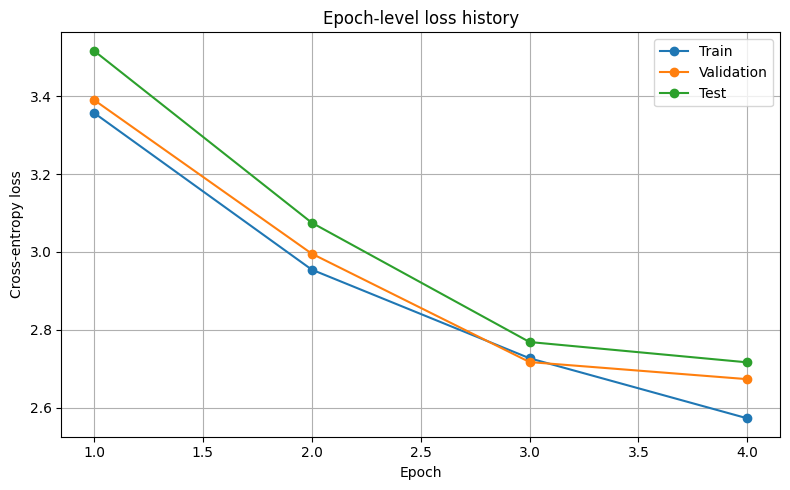

In [40]:
import matplotlib.pyplot as plt
import torch

ckpt_for_plot = torch.load(LATEST_CKPT, map_location="cpu")

# Keep only epoch-level metrics
train_epoch_plot = ckpt_for_plot.get("train_losses", [])
val_epoch_plot = ckpt_for_plot.get("val_losses", [])
test_epoch_plot = ckpt_for_plot.get("test_losses", [])
samples_done_plot = ckpt_for_plot.get("samples_trained_so_far", None)

print("Samples trained so far:", samples_done_plot)
print("Saved epoch train losses:", train_epoch_plot)
print("Saved epoch val losses:", val_epoch_plot)
print("Saved epoch test losses:", test_epoch_plot)

# ---------- EPOCH-LEVEL PLOT ----------
if len(train_epoch_plot) > 0 or len(val_epoch_plot) > 0 or len(test_epoch_plot) > 0:
    plt.figure(figsize=(8,5))

    if len(train_epoch_plot) > 0:
        plt.plot(range(1, len(train_epoch_plot)+1), train_epoch_plot, marker="o", label="Train")

    if len(val_epoch_plot) > 0:
        plt.plot(range(1, len(val_epoch_plot)+1), val_epoch_plot, marker="o", label="Validation")

    if len(test_epoch_plot) > 0:
        plt.plot(range(1, len(test_epoch_plot)+1), test_epoch_plot, marker="o", label="Test")

    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.title("Epoch-level loss history")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("lab2_epoch_loss_history.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No epoch-level losses found in checkpoint.")